<a href="https://colab.research.google.com/github/hair-loss/Digital-Image-Processing-Homeworks/blob/main/%EC%98%81%EC%83%81%EC%B2%98%EB%A6%AC_HW4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


(282, 375, 3)


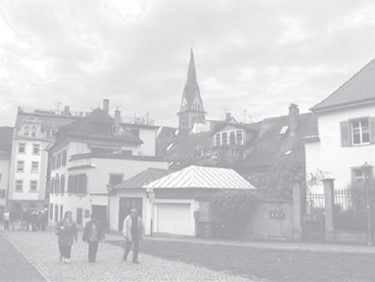

In [3]:
hist_half = cv2.imread('/content/drive/MyDrive/ImageProcessingAssignment/hist_half.jpg')
print(hist_half.shape)
cv2_imshow(hist_half)

In [4]:
hist_blue = cv2.calcHist([hist_half], [0], None, [256], [0,256]) #cv2.calcHist(image, channel, mask, histSize, ranges)
#image : 영상, 이미지 (배열)
#channel : 히스토그램 계산의 차원 목록
#mask : 특정 영역을 계산하기 위한 마스크 행렬
#histSize : 히스토그램 배열의 크기
#ranges : 히스토그램의 범위 (Y축, 화소의 강도 / 대부분[0,256])
hist_red = cv2.calcHist([hist_half], [1], None, [256], [0,256])
hist_green = cv2.calcHist([hist_half], [2], None, [256], [0,256])

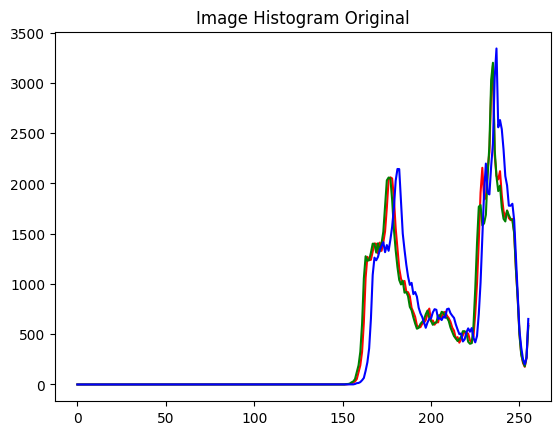

In [5]:
plt.title("Image Histogram Original")
plt.plot(hist_red, color='r')
plt.plot(hist_green, color='g')
plt.plot(hist_blue, color='b')
plt.show()

In [6]:
hist_red.shape

(256, 1)

In [7]:
hist_new = cv2.imread('/content/drive/MyDrive/ImageProcessingAssignment/hist_half.jpg')
hist_new.shape

(282, 375, 3)

In [8]:
hist_new = hist_new.astype(np.float32)
for i in range(hist_new.shape[2]):
  high = np.max(hist_new[:, :, i])
  low = np.min(hist_new[:,:,i])
  for j in range(hist_new.shape[0]):
    for k in range(hist_new.shape[1]):
      value = hist_new[j, k, i]
      new_value = (value - low)/(high-low)*255
      hist_new[j, k, i] = new_value
hist_new = hist_new.astype(np.uint8)

In [9]:
hist_blue_new = cv2.calcHist([hist_new], [0], None, [256], [0, 256])
hist_green_new = cv2.calcHist([hist_new], [1], None, [256], [0, 256])
hist_red_new = cv2.calcHist([hist_new], [2], None, [256], [0, 256])

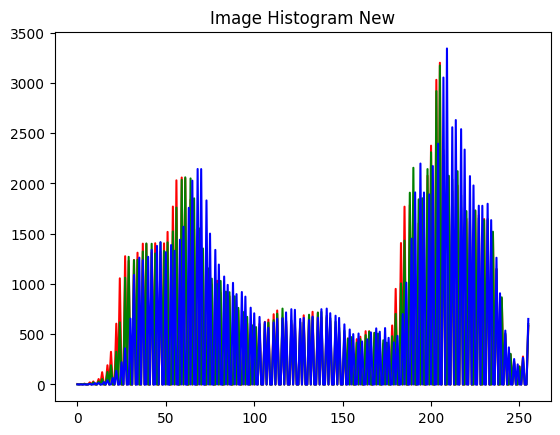

In [10]:
plt.figure()
plt.title("Image Histogram New")
plt.plot(hist_red_new, color='r')
plt.plot(hist_green_new, color='g')
plt.plot(hist_blue_new, color='b')
plt.show()

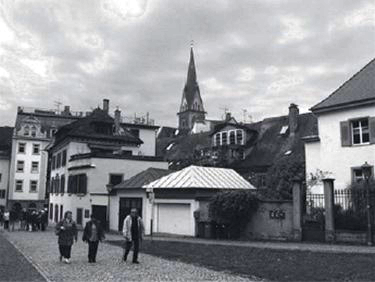

In [11]:
cv2_imshow(hist_new)

Original image


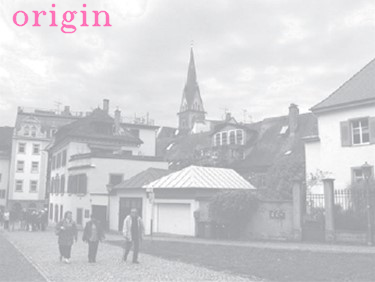

New image


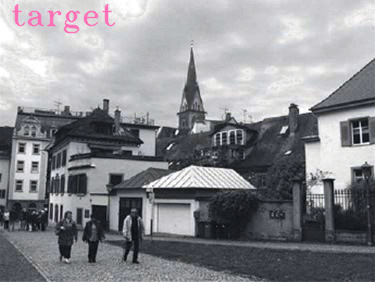

In [14]:
print("Original image")
cv2.putText(hist_half, "origin", (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 1, (180,105, 255), 1, cv2.LINE_AA)
cv2_imshow(hist_half)
print("New image")
cv2.putText(hist_new, "target", (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 1, (180,105, 255), 1, cv2.LINE_AA)
cv2_imshow(hist_new)

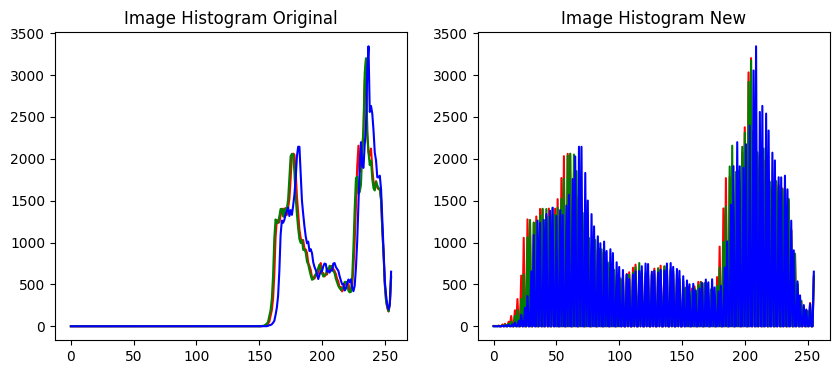

In [15]:
plt.figure(figsize = (10, 4))
plt.subplot(1, 2, 1)
plt.title("Image Histogram Original")
plt.plot(hist_red, color='r')
plt.plot(hist_green, color='g')
plt.plot(hist_blue, color='b')
plt.subplot(1, 2, 2)
plt.title("Image Histogram New")
plt.plot(hist_red_new, color='r')
plt.plot(hist_green_new, color='g')
plt.plot(hist_blue_new, color='b')
plt.show()